# 🎼 Énigmes & Merveilles de Marcus du Sautoy

*Un notebook démo pour matheux, dans l'esprit de Marcus du Sautoy — mathématicien à Oxford, titulaire de
la chaire Simonyi pour la compréhension publique des sciences (succédant à Richard Dawkins), spécialiste
de théorie des groupes et de symétrie, auteur de *The Music of the Primes*, *Finding Moonshine*, *The
Number Mysteries*, *The Creativity Code* et *Around the World in 80 Games*.*

Ce notebook regroupe **8 énigmes / explorations** directement issues (ou inspirées) de ses livres et
conférences, dans la continuité de la démo JupyterLab entamée avec Gardner, Pickover, Stewart et
Delahaye — même recette : calcul, texte, visualisation et interactivité réunis dans un seul document.

**Sommaire**

1. [La fonction zêta de Riemann et la musique des nombres premiers](#1)
2. [Le groupe de symétrie du Rubik's Cube](#2)
3. [Campanologie : les cloches et les groupes de permutations](#3)
4. [Le jeu de Hex : la topologie sans match nul](#4)
5. [La course des nombres premiers](#5) — le biais de Tchebychev
6. [Le groupe Monstre et le Monstrous Moonshine](#6)
7. [Les gammes musicales comme groupe cyclique Z/12Z](#7)
8. [Le code de la créativité : art génératif par L-system](#8)
9. [Bac à sable interactif](#9)

> 💡 Astuce démo : `Run All Cells` en ouverture, tout se recalcule sous les yeux du public.


## 1. La fonction zêta de Riemann et la musique des nombres premiers <a id="1"></a>

*The Music of the Primes* (2003) tire son titre d'une idée que du Sautoy adore développer en conférence :
les zéros non triviaux de la fonction zêta de Riemann, tous alignés (conjecturalement) sur la droite
critique $\text{Re}(s)=1/2$, se comportent comme les fréquences propres d'un instrument — chacun ajoute
une "harmonique" qui, superposée aux autres, dessine peu à peu l'escalier irrégulier des nombres premiers.
Ci-dessous, le module de $\zeta(1/2+it)$ le long de la droite critique : les creux qui touchent zéro sont
les premiers zéros non triviaux.

Cinq premiers zéros non triviaux (partie imaginaire) :
  14.134725
  21.022040
  25.010858
  30.424876
  32.935062


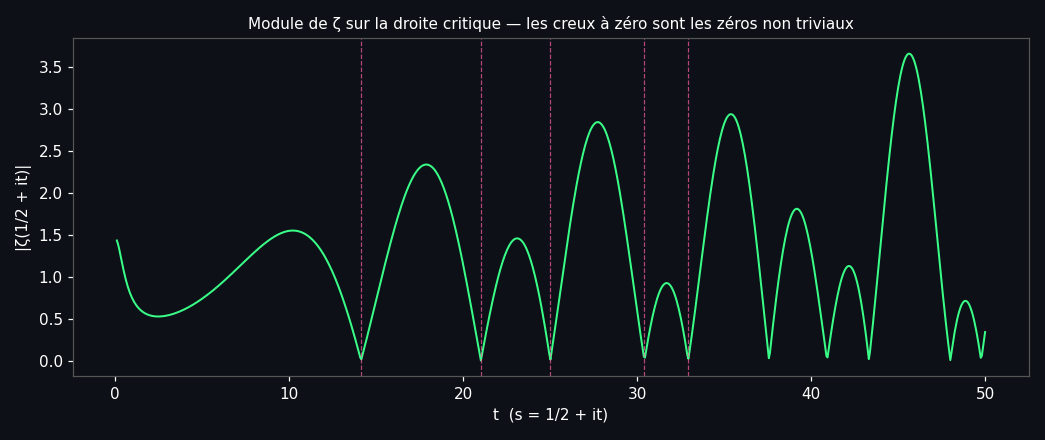

In [1]:
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import mpmath as mp
import numpy as np

mp.mp.dps = 20
ts = np.linspace(0.1, 50, 800)
vals = [abs(mp.zeta(0.5 + 1j*float(t))) for t in ts]

zeros = [mp.zetazero(n) for n in range(1, 6)]
zero_ts = [float(mp.im(z)) for z in zeros]

fig, ax = plt.subplots(figsize=(9.5, 4), facecolor="#0d1117")
ax.set_facecolor("#0d1117")
ax.plot(ts, vals, color="#39ff88", lw=1.3)
for zt in zero_ts:
    ax.axvline(zt, color="#ff5da2", lw=0.8, ls="--", alpha=0.7)
ax.set_xlabel("t  (s = 1/2 + it)", color="white")
ax.set_ylabel("|ζ(1/2 + it)|", color="white")
ax.tick_params(colors="white")
for spine in ax.spines.values(): spine.set_color("#555")
ax.set_title("Module de ζ sur la droite critique — les creux à zéro sont les zéros non triviaux", color="white", fontsize=10)
plt.tight_layout()
plt.savefig("out1.png", dpi=110, facecolor=fig.get_facecolor())
print("Cinq premiers zéros non triviaux (partie imaginaire) :")
for zt in zero_ts:
    print(f"  {zt:.6f}")


La **formule explicite de Riemann** relie exactement la fonction de comptage des nombres premiers à une
somme sur *tous* les zéros de zêta — chaque zéro ajouté est littéralement une nouvelle harmonique qui
affine l'approximation de l'escalier des premiers. C'est la démonstration favorite de du Sautoy pour
montrer que les zéros de zêta "contiennent" toute l'information sur la distribution des nombres premiers.

Plus on ajoute de zéros (d'« harmoniques »), plus l'escalier des nombres premiers se dessine précisément.


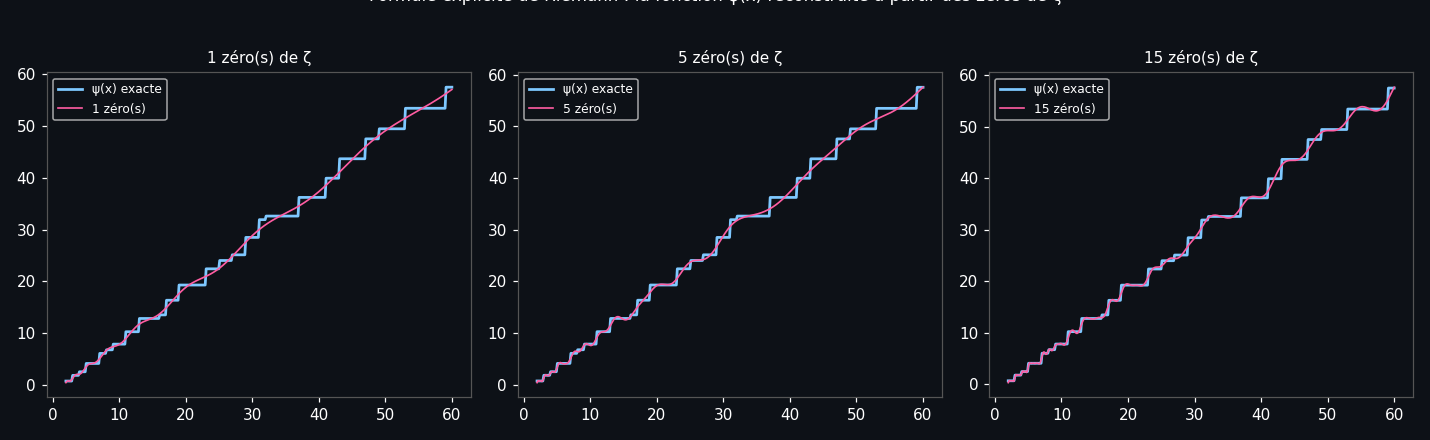

In [2]:
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import mpmath as mp
import numpy as np

mp.mp.dps = 20

def psi_exact(x):
    # fonction de Chebyshev psi(x) = somme des ln(p) pour p^k <= x
    total = 0.0
    n = 2
    while n <= x:
        # test rapide de primalité
        is_p = n > 1
        i = 2
        while i*i <= n:
            if n % i == 0:
                is_p = False
                break
            i += 1
        if is_p:
            pk = n
            while pk <= x:
                total += np.log(n)
                pk *= n
        n += 1
    return total

xs = np.linspace(2, 60, 400)
exact = [psi_exact(x) for x in xs]

N_ZEROS = 15
zeros = [mp.zetazero(n) for n in range(1, N_ZEROS+1)]

def psi_approx(x, n_zeros):
    total = mp.mpf(x) - mp.log(2*mp.pi) - 0.5*mp.log(1 - x**-2)
    for z in zeros[:n_zeros]:
        rho = z
        total -= 2 * mp.re(mp.mpf(x)**rho / rho)
    return float(total)

fig, axes = plt.subplots(1, 3, figsize=(13, 4), facecolor="#0d1117")
for ax, nz in zip(axes, [1, 5, 15]):
    ax.set_facecolor("#0d1117")
    approx = [psi_approx(x, nz) for x in xs]
    ax.plot(xs, exact, color="#7ec8ff", lw=1.8, label="ψ(x) exacte")
    ax.plot(xs, approx, color="#ff5da2", lw=1.1, label=f"{nz} zéro(s)")
    ax.tick_params(colors="white")
    ax.set_title(f"{nz} zéro(s) de ζ", color="white", fontsize=10)
    for spine in ax.spines.values(): spine.set_color("#555")
    ax.legend(facecolor="#0d1117", labelcolor="white", fontsize=8)
fig.suptitle("Formule explicite de Riemann : la fonction ψ(x) reconstruite à partir des zéros de ζ", color="white", fontsize=11, y=1.03)
plt.tight_layout()
plt.savefig("out1b.png", dpi=110, facecolor=fig.get_facecolor())
print("Plus on ajoute de zéros (d'« harmoniques »), plus l'escalier des nombres premiers se dessine précisément.")


## 2. Le groupe de symétrie du Rubik's Cube <a id="2"></a>

Dans ses conférences grand public, du Sautoy utilise souvent le Rubik's Cube pour donner une intuition
concrète de la théorie des groupes : chaque mouvement du cube est un élément d'un groupe de permutations,
et la question "peut-on toujours résoudre le cube ?" est une question de théorie des groupes (le groupe
engendré par les mouvements de base). L'ordre de ce groupe — le nombre total de configurations
atteignables — se calcule à partir des permutations et orientations possibles des coins et des arêtes.

8! × 3^7 = 88,179,840  (coins)
12! × 2^11 = 980,995,276,800  (arêtes)
Ordre du groupe du Rubik's Cube : 43,252,003,274,489,856,000
≈ 4.325e+19


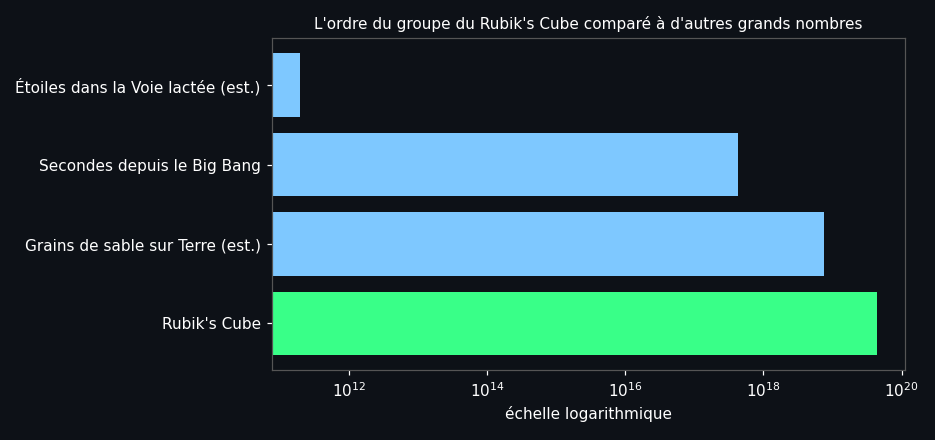

In [3]:
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
from math import factorial

# Ordre du groupe de symétrie du Rubik's Cube (formule classique)
# 8 coins : 8! permutations x 3^7 orientations (la 8e est déterminée)
# 12 arêtes : 12! permutations x 2^11 orientations (la 12e est déterminée)
# divisé par 2 car seules la moitié des combinaisons de permutations sont atteignables
corners_perm = factorial(8)
corners_orient = 3**7
edges_perm = factorial(12)
edges_orient = 2**11

group_order = (corners_perm * corners_orient * edges_perm * edges_orient) // 2
print(f"8! × 3^7 = {corners_perm * corners_orient:,}  (coins)")
print(f"12! × 2^11 = {edges_perm * edges_orient:,}  (arêtes)")
print(f"Ordre du groupe du Rubik's Cube : {group_order:,}")
print(f"≈ {group_order:.3e}")

# comparaison avec d'autres grandeurs pour donner une intuition d'échelle
comparisons = {
    "Rubik's Cube": float(group_order),
    "Grains de sable sur Terre (est.)": 7.5e18,
    "Secondes depuis le Big Bang": 4.35e17,
    "Étoiles dans la Voie lactée (est.)": 2e11,
}

fig, ax = plt.subplots(figsize=(8.5, 4), facecolor="#0d1117")
ax.set_facecolor("#0d1117")
names = list(comparisons.keys())
values = list(comparisons.values())
colors = ["#39ff88" if n == "Rubik's Cube" else "#7ec8ff" for n in names]
ax.barh(names, values, color=colors)
ax.set_xscale("log")
ax.set_xlabel("échelle logarithmique", color="white")
ax.tick_params(colors="white")
for spine in ax.spines.values(): spine.set_color("#555")
ax.set_title("L'ordre du groupe du Rubik's Cube comparé à d'autres grands nombres", color="white", fontsize=10)
plt.tight_layout()
plt.savefig("out2.png", dpi=110, facecolor=fig.get_facecolor())


## 3. Campanologie : les cloches et les groupes de permutations <a id="3"></a>

Du Sautoy est un adepte reconnu de la sonnerie de cloches anglaise (*change ringing*) et l'a souvent
utilisée pour vulgariser la théorie des groupes : chaque "changement" est une permutation des cloches, et
une méthode de sonnerie complète explore méthodiquement les éléments d'un groupe de permutations sans
jamais répéter le même ordre avant d'avoir fait le tour. Le **Plain Hunt**, méthode la plus simple,
échange des paires de cloches adjacentes en alternance jusqu'au retour à l'ordre initial.

Plain Hunt sur 4 cloches — retour à l'ordre initial après 8 changements :
  (1, 2, 3, 4)
  (2, 1, 4, 3)
  (2, 4, 1, 3)
  (4, 2, 3, 1)
  (4, 3, 2, 1)
  (3, 4, 1, 2)
  (3, 1, 4, 2)
  (1, 3, 2, 4)
  (1, 2, 3, 4)


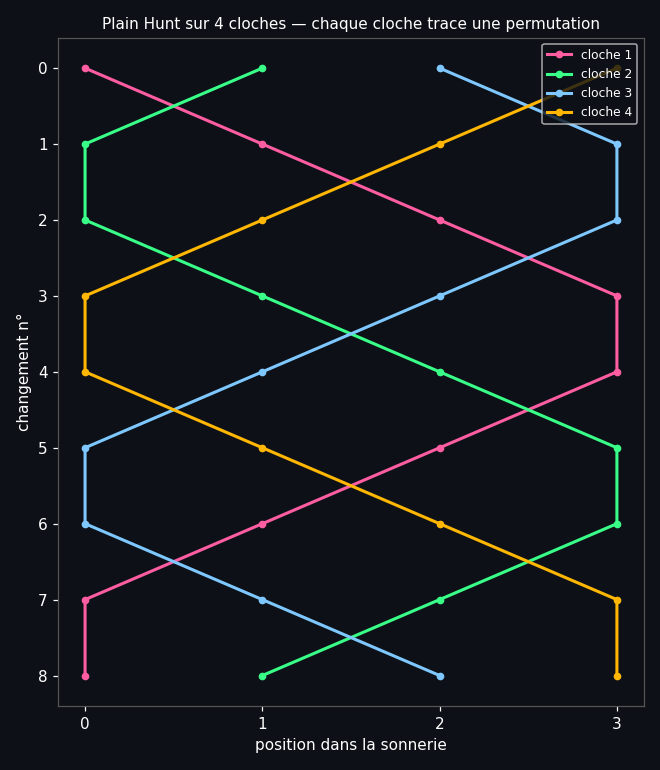

In [4]:
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt

# "Plain Hunt" sur n cloches : une méthode de base de campanologie anglaise.
# Chaque "changement" échange des paires adjacentes de cloches, alternativement
# à partir de la position 0 puis de la position 1 — jusqu'au retour à l'ordre initial.
def plain_hunt(n):
    perm = list(range(1, n+1))
    rows = [tuple(perm)]
    forward = True
    for _ in range(2*n):
        new_perm = perm[:]
        start = 0 if forward else 1
        for i in range(start, n-1, 2):
            new_perm[i], new_perm[i+1] = new_perm[i+1], new_perm[i]
        perm = new_perm
        rows.append(tuple(perm))
        forward = not forward
    return rows

rows = plain_hunt(4)
print(f"Plain Hunt sur 4 cloches — retour à l'ordre initial après {len(rows)-1} changements :")
for r in rows:
    print(" ", r)

fig, ax = plt.subplots(figsize=(6, 7), facecolor="#0d1117")
ax.set_facecolor("#0d1117")
colors_bell = ["#ff5da2", "#39ff88", "#7ec8ff", "#ffb703"]
n = len(rows[0])
for bell in range(1, n+1):
    xs = [row.index(bell) for row in rows]
    ys = list(range(len(rows)))
    ax.plot(xs, ys, color=colors_bell[bell-1], lw=2, marker="o", markersize=4, label=f"cloche {bell}")
ax.invert_yaxis()
ax.set_xticks(range(n))
ax.set_xlabel("position dans la sonnerie", color="white")
ax.set_ylabel("changement n°", color="white")
ax.tick_params(colors="white")
for spine in ax.spines.values(): spine.set_color("#555")
ax.legend(facecolor="#0d1117", labelcolor="white", loc="upper right", fontsize=8)
ax.set_title("Plain Hunt sur 4 cloches — chaque cloche trace une permutation", color="white", fontsize=10)
plt.tight_layout()
plt.savefig("out3.png", dpi=110, facecolor=fig.get_facecolor())


## 4. Le jeu de Hex : la topologie sans match nul <a id="4"></a>

Présenté dans *Around the World in 80 Games* : sur un plateau losange d'hexagones, deux joueurs tentent
chacun de relier leurs deux bords opposés par une chaîne continue de leurs pions. Le **théorème de Hex**
(John Nash, 1952) garantit qu'il ne peut jamais y avoir de match nul : dès que le plateau est entièrement
rempli, l'un des deux joueurs a nécessairement formé une chaîne gagnante — un résultat de pure topologie
combinatoire, remarquablement simple à énoncer mais dont la preuve rigoureuse est subtile.

Plateau 7x7 rempli aléatoirement -> vainqueur : joueur 2
(le théorème de Hex garantit qu'un des deux joueurs gagne toujours, jamais de match nul)


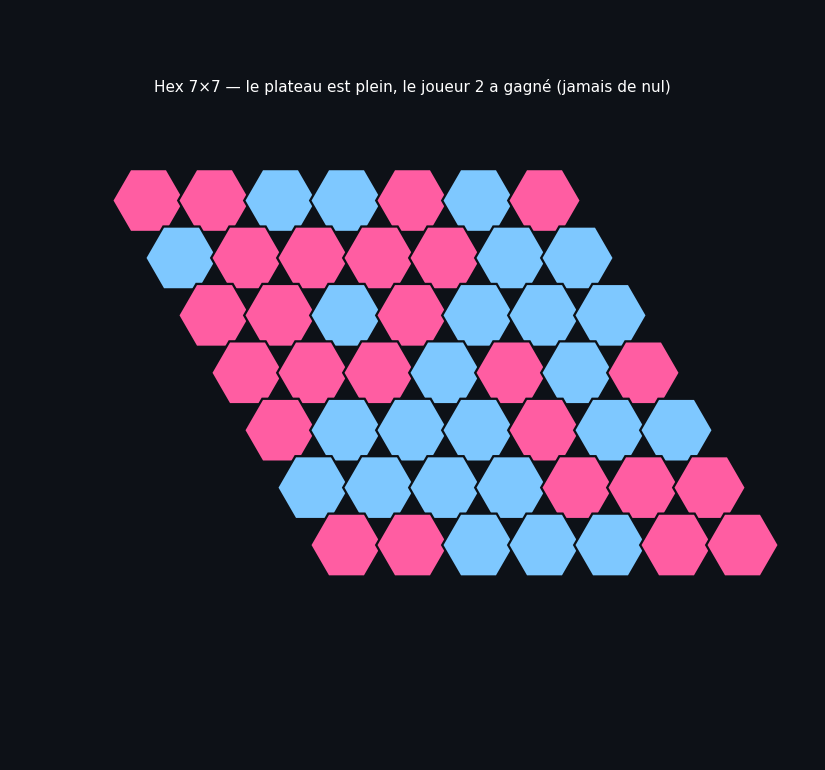

In [5]:
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
from matplotlib.patches import RegularPolygon
import numpy as np
import random
random.seed(5)

# Le jeu de Hex : plateau losange de nx n hexagones, deux joueurs relient
# leurs deux bords opposés. Théorème (Nash, 1952) : il ne peut jamais y avoir
# de match nul — dès que le plateau est rempli, un des deux joueurs a
# nécessairement formé une chaîne reliant ses deux bords. C'est ce résultat
# topologique que du Sautoy aime présenter pour illustrer les liens entre
# jeux combinatoires et théorie des graphes.

SIZE = 7
board = [[0]*SIZE for _ in range(SIZE)]
# partie aléatoire jouée jusqu'au remplissage complet du plateau
cells = [(r,c) for r in range(SIZE) for c in range(SIZE)]
random.shuffle(cells)
for i,(r,c) in enumerate(cells):
    board[r][c] = 1 if i % 2 == 0 else 2

def has_path(board, player):
    size = len(board)
    visited = [[False]*size for _ in range(size)]
    stack = []
    if player == 1:
        stack = [(r,0) for r in range(size) if board[r][0]==1]
    else:
        stack = [(0,c) for c in range(size) if board[0][c]==2]
    neighbors = [(-1,0),(-1,1),(0,-1),(0,1),(1,-1),(1,0)]
    while stack:
        r,c = stack.pop()
        if visited[r][c]: continue
        visited[r][c] = True
        if player == 1 and c == size-1: return True
        if player == 2 and r == size-1: return True
        for dr,dc in neighbors:
            nr,nc = r+dr, c+dc
            if 0<=nr<size and 0<=nc<size and not visited[nr][nc] and board[nr][nc]==player:
                stack.append((nr,nc))
    return False

winner = 1 if has_path(board,1) else (2 if has_path(board,2) else 0)
print(f"Plateau {SIZE}x{SIZE} rempli aléatoirement -> vainqueur : joueur {winner}")
print("(le théorème de Hex garantit qu'un des deux joueurs gagne toujours, jamais de match nul)")

fig, ax = plt.subplots(figsize=(7.5, 7), facecolor="#0d1117")
ax.set_facecolor("#0d1117")
colors_map = {0: "#333", 1: "#ff5da2", 2: "#7ec8ff"}
for r in range(SIZE):
    for c in range(SIZE):
        x = c*1.0 + r*0.5
        y = -r*0.87
        hexagon = RegularPolygon((x,y), numVertices=6, radius=0.55, orientation=np.pi/6,
                                  facecolor=colors_map[board[r][c]], edgecolor="#0d1117", linewidth=1.5)
        ax.add_patch(hexagon)
ax.set_xlim(-2, SIZE+3)
ax.set_ylim(-SIZE*0.87-1, 1.5)
ax.set_aspect("equal")
ax.set_axis_off()
ax.set_title(f"Hex {SIZE}×{SIZE} — le plateau est plein, le joueur {winner} a gagné (jamais de nul)", color="white", fontsize=10)
plt.tight_layout()
plt.savefig("out4.png", dpi=110, facecolor=fig.get_facecolor())


## 5. La course des nombres premiers <a id="5"></a>

Thème classique de *The Music of the Primes* : si l'on classe les nombres premiers impairs selon leur
reste modulo 4 (1 ou 3), on observe presque toujours plus de premiers $\equiv 3 \pmod 4$ que
$\equiv 1 \pmod 4$ jusqu'à une certaine borne — un phénomène remarqué par Tchebychev dès 1853. Les deux
comportent asymptotiquement la même densité (théorème de la progression arithmétique de Dirichlet), mais
la "course" reste étonnamment et systématiquement biaisée en faveur du camp "3 mod 4" sur de très longues
plages.

Jusqu'à 200,000 : 9006 nombres premiers ≡ 3 (mod 4), 8977 ≡ 1 (mod 4)
Tchebychev (1853) l'avait remarqué : la course est presque toujours en tête pour '3 mod 4'.


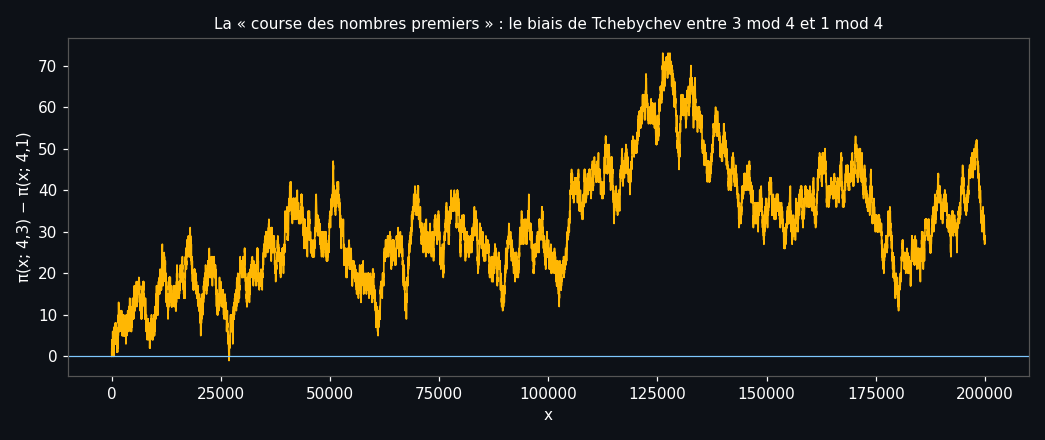

In [6]:
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import numpy as np

def sieve(n):
    is_p = np.ones(n+1, dtype=bool)
    is_p[:2] = False
    for i in range(2, int(n**0.5)+1):
        if is_p[i]:
            is_p[i*i::i] = False
    return is_p

N = 200000
is_p = sieve(N)
primes = np.nonzero(is_p)[0]

count_4k1 = 0   # p ≡ 1 (mod 4)
count_4k3 = 0   # p ≡ 3 (mod 4)
xs, diff = [], []
for p in primes:
    if p == 2: continue
    if p % 4 == 1: count_4k1 += 1
    else: count_4k3 += 1
    xs.append(p)
    diff.append(count_4k3 - count_4k1)

print(f"Jusqu'à {N:,} : {count_4k3} nombres premiers ≡ 3 (mod 4), {count_4k1} ≡ 1 (mod 4)")
print("Tchebychev (1853) l'avait remarqué : la course est presque toujours en tête pour '3 mod 4'.")

fig, ax = plt.subplots(figsize=(9.5, 4), facecolor="#0d1117")
ax.set_facecolor("#0d1117")
ax.plot(xs, diff, color="#ffb703", lw=1.1)
ax.axhline(0, color="#7ec8ff", lw=0.8)
ax.set_xlabel("x", color="white")
ax.set_ylabel("π(x; 4,3) − π(x; 4,1)", color="white")
ax.tick_params(colors="white")
for spine in ax.spines.values(): spine.set_color("#555")
ax.set_title("La « course des nombres premiers » : le biais de Tchebychev entre 3 mod 4 et 1 mod 4", color="white", fontsize=10)
plt.tight_layout()
plt.savefig("out5.png", dpi=110, facecolor=fig.get_facecolor())


## 6. Le groupe Monstre et le Monstrous Moonshine <a id="6"></a>

*Finding Moonshine* (2008) raconte la quête de du Sautoy pour comprendre le plus grand des groupes
simples sporadiques, le **groupe Monstre** (environ $8 \times 10^{53}$ éléments). En 1978, John McKay
remarque une coïncidence numérique stupéfiante : le premier coefficient non trivial de la fonction
modulaire $j$ — un objet d'analyse complexe apparemment sans rapport — s'écrit exactement comme une somme
de dimensions des représentations irréductibles du Monstre. Cette observation, baptisée "Monstrous
Moonshine" par Conway et Norton, sera prouvée par Richard Borcherds en 1992 (médaille Fields 1998).

Coefficients de j(q) = 1/q + 744 + 196884 q + 21493760 q² + ...
Dimensions des représentations du Monstre : 1, 196883, 21296876, ...

196884 = 1 + 196883 = 196884  -> coïncidence vérifiée !
21493760 = 1 + 196883 + 21296876 = 21493760  -> coïncidence vérifiée !


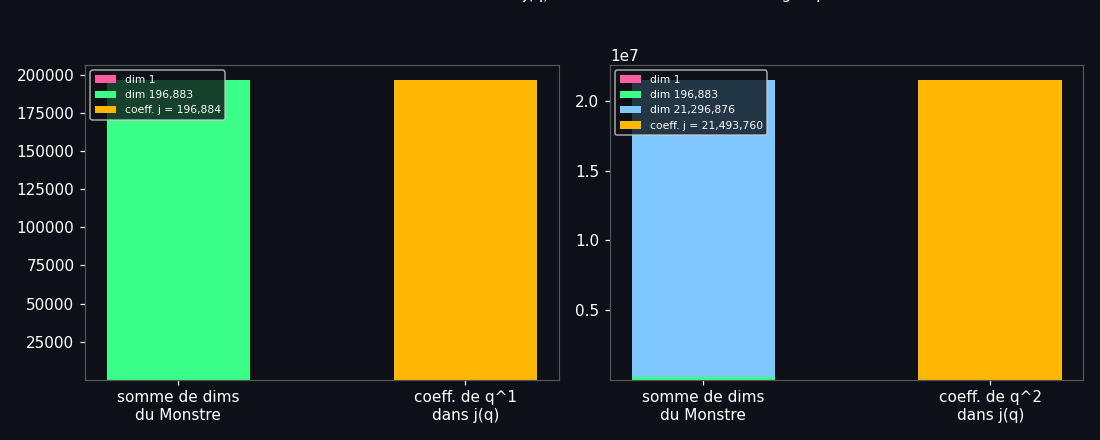

In [7]:
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt

# Coefficients de la fonction modulaire j (OEIS A000521) et dimensions des plus
# petites représentations irréductibles du groupe Monstre (OEIS A001379) —
# l'observation de John McKay (1978) qui a donné naissance au "Monstrous Moonshine"
# (Conway & Norton, 1979 ; démontré par Borcherds en 1992, médaille Fields 1998).

j_coeffs = {1: 196884, 2: 21493760}
monster_dims = [1, 196883, 21296876]

print("Coefficients de j(q) = 1/q + 744 + 196884 q + 21493760 q² + ...")
print("Dimensions des représentations du Monstre : 1, 196883, 21296876, ...\n")

relation1 = monster_dims[0] + monster_dims[1]
print(f"196884 = 1 + 196883 = {relation1}  -> {'coïncidence vérifiée !' if relation1 == j_coeffs[1] else 'erreur'}")

relation2 = monster_dims[0] + monster_dims[1] + monster_dims[2]
print(f"21493760 = 1 + 196883 + 21296876 = {relation2}  -> {'coïncidence vérifiée !' if relation2 == j_coeffs[2] else 'erreur'}")

fig, axes = plt.subplots(1, 2, figsize=(10, 4), facecolor="#0d1117")
for ax, (n, target) in zip(axes, j_coeffs.items()):
    ax.set_facecolor("#0d1117")
    parts = monster_dims[:n+1]
    bottom = 0
    colors = ["#ff5da2", "#39ff88", "#7ec8ff"]
    for i, part in enumerate(parts):
        ax.bar(0, part, bottom=bottom, color=colors[i % len(colors)], width=0.5,
               label=f"dim {part:,}")
        bottom += part
    ax.bar(1, target, color="#ffb703", width=0.5, label=f"coeff. j = {target:,}")
    ax.set_xticks([0, 1]); ax.set_xticklabels(["somme de dims\ndu Monstre", f"coeff. de q^{n}\ndans j(q)"], color="white")
    ax.tick_params(colors="white")
    for spine in ax.spines.values(): spine.set_color("#555")
    ax.legend(facecolor="#0d1117", labelcolor="white", fontsize=7, loc="upper left")
fig.suptitle("Monstrous Moonshine : les coefficients de j(q) = sommes de dimensions du groupe Monstre", color="white", fontsize=10, y=1.03)
plt.tight_layout()
plt.savefig("out6.png", dpi=110, facecolor=fig.get_facecolor())


## 7. Les gammes musicales comme groupe cyclique Z/12Z <a id="7"></a>

Passionné de musique (il a joué de la trompette et écrit sur les liens entre mathématiques et composition),
du Sautoy aime montrer que l'octave, découpée en 12 demi-tons égaux, forme le **groupe cyclique Z/12Z** :
transposer une mélodie revient à ajouter une constante modulo 12. Le **cycle des quintes** — ajouter 7
(une quinte) modulo 12 — engendre à lui seul tout le groupe, car 7 et 12 sont premiers entre eux ; c'est
ce principe qui organise tout l'accordage occidental depuis Pythagore.

Cycle des quintes (ajouter 7 mod 12 à chaque étape) :
Do -> Sol -> Ré -> La -> Mi -> Si -> Fa# -> Do# -> Sol# -> Ré# -> La# -> Fa

On revient à Do après 12 quintes : Fa + une quinte = Do
7 et 12 étant premiers entre eux, le cycle des quintes engendre tout le groupe Z/12Z.


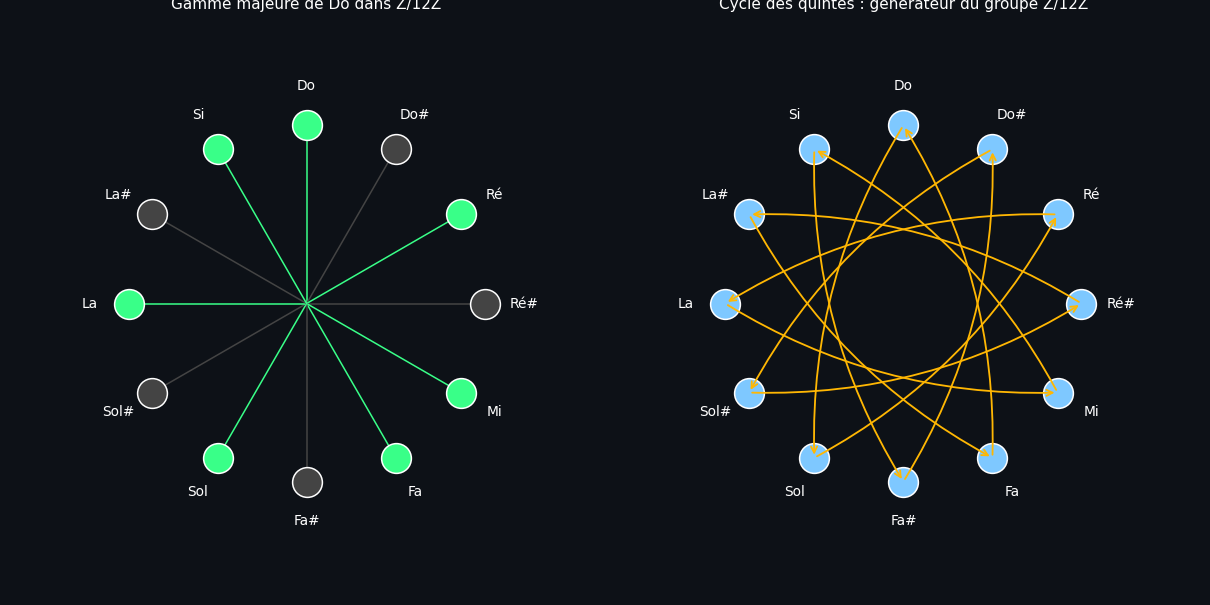

In [8]:
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import numpy as np

# Du Sautoy aime montrer que l'octave découpée en 12 demi-tons forme le groupe
# cyclique Z/12Z : transposer une mélodie = additionner une constante modulo 12 ;
# la gamme majeure est un sous-ensemble de Z/12Z engendré par des intervalles de quinte.

NOTES = ["Do","Do#","Ré","Ré#","Mi","Fa","Fa#","Sol","Sol#","La","La#","Si"]
major_scale_steps = [0,2,4,5,7,9,11]  # gamme majeure de Do

# Cycle des quintes : partir de Do et ajouter 7 (une quinte) modulo 12, 12 fois
fifths_cycle = [(0 + 7*k) % 12 for k in range(12)]
print("Cycle des quintes (ajouter 7 mod 12 à chaque étape) :")
print(" -> ".join(NOTES[n] for n in fifths_cycle))
print(f"\nOn revient à Do après 12 quintes : {NOTES[fifths_cycle[-1]]} + une quinte = {NOTES[0]}")
print("7 et 12 étant premiers entre eux, le cycle des quintes engendre tout le groupe Z/12Z.")

fig, axes = plt.subplots(1, 2, figsize=(11, 5.5), facecolor="#0d1117")
for ax in axes: ax.set_facecolor("#0d1117")

# Cercle chromatique avec la gamme majeure surlignée
ax = axes[0]
angles = [np.pi/2 - 2*np.pi*i/12 for i in range(12)]
xs = [np.cos(a) for a in angles]; ys = [np.sin(a) for a in angles]
for i in range(12):
    color = "#39ff88" if i in major_scale_steps else "#444"
    ax.plot([0,xs[i]], [0,ys[i]], color=color, lw=1)
    ax.scatter([xs[i]],[ys[i]], s=380, color=color, zorder=3, edgecolor="white")
    ax.text(xs[i]*1.22, ys[i]*1.22, NOTES[i], color="white", ha="center", va="center", fontsize=9)
ax.set_xlim(-1.6,1.6); ax.set_ylim(-1.6,1.6); ax.set_aspect("equal"); ax.set_axis_off()
ax.set_title("Gamme majeure de Do dans Z/12Z", color="white", fontsize=10)

# Cycle des quintes
ax = axes[1]
angles2 = [np.pi/2 - 2*np.pi*i/12 for i in range(12)]
xs2 = [np.cos(a) for a in angles2]; ys2 = [np.sin(a) for a in angles2]
for i in range(12):
    ax.scatter([xs2[i]],[ys2[i]], s=380, color="#7ec8ff", zorder=3, edgecolor="white")
    ax.text(xs2[i]*1.22, ys2[i]*1.22, NOTES[i], color="white", ha="center", va="center", fontsize=9)
for k in range(12):
    a, b = fifths_cycle[k], fifths_cycle[(k+1) % 12]
    ax.annotate("", xy=(xs2[b],ys2[b]), xytext=(xs2[a],ys2[a]),
                arrowprops=dict(arrowstyle="->", color="#ffb703", lw=1.2,
                                 connectionstyle="arc3,rad=0.15"))
ax.set_xlim(-1.6,1.6); ax.set_ylim(-1.6,1.6); ax.set_aspect("equal"); ax.set_axis_off()
ax.set_title("Cycle des quintes : générateur du groupe Z/12Z", color="white", fontsize=10)

plt.tight_layout()
plt.savefig("out7.png", dpi=110, facecolor=fig.get_facecolor())


## 8. Le code de la créativité : art génératif par L-system <a id="8"></a>

*The Creativity Code* (2019) interroge frontalement ce que signifie "créer" quand un algorithme peut
composer de la musique, peindre, ou jouer au Go de façon inattendue. Illustration minimale du propos : un
**L-system**, simple grammaire de réécriture de chaînes de caractères (inventée par le biologiste Aristid
Lindenmayer pour modéliser la croissance des plantes), engendre ici une variante de la célèbre "courbe du
dragon" — une forme d'une richesse visuelle qui semble "inventée", alors qu'elle résulte de règles
parfaitement mécaniques appliquées sans relâche.

Chaîne générée par le L-system après 12 itérations : 16382 caractères


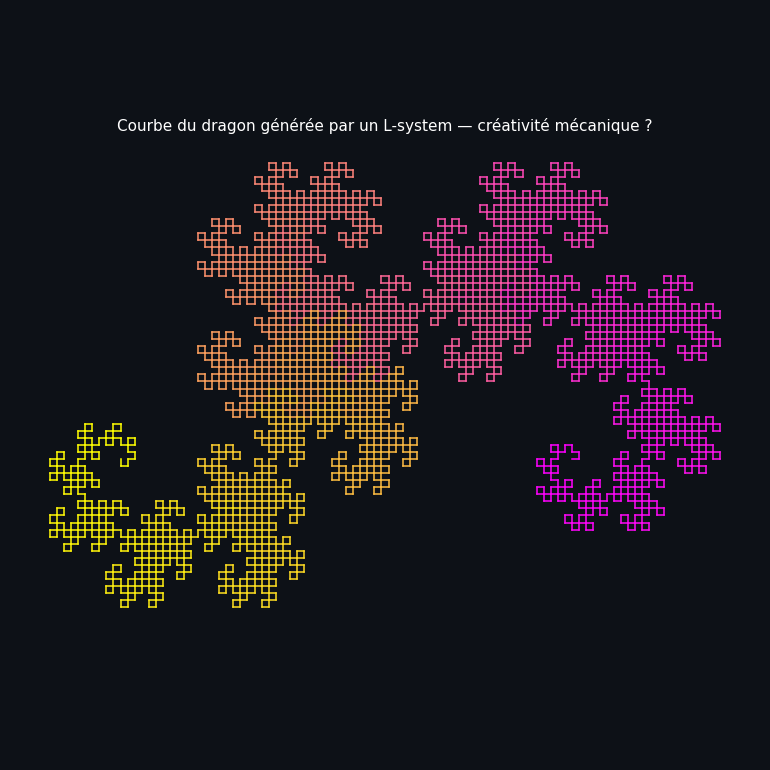

In [9]:
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import numpy as np

# Dans "The Creativity Code", du Sautoy interroge ce que "créer" veut dire pour
# une machine. Illustration minimale avec un L-system (grammaire de réécriture
# de chaînes, comme celles utilisées pour générer des plantes ou des motifs) :
# une règle purement mécanique peut produire des formes d'une complexité
# qui semble "inventée".

def l_system(axiom, rules, iterations):
    s = axiom
    for _ in range(iterations):
        s = "".join(rules.get(ch, ch) for ch in s)
    return s

# Règle inspirée de la "courbe du dragon" — motif fractal auto-similaire
axiom = "FX"
rules = {"X": "X+YF+", "Y": "-FX-Y"}
s = l_system(axiom, rules, 12)
print(f"Chaîne générée par le L-system après 12 itérations : {len(s)} caractères")

x, y, angle = 0.0, 0.0, 0.0
path = [(x, y)]
step = 1.0
for ch in s:
    if ch == "F":
        x += step * np.cos(angle)
        y += step * np.sin(angle)
        path.append((x, y))
    elif ch == "+":
        angle += np.pi/2
    elif ch == "-":
        angle -= np.pi/2

xs, ys = zip(*path)
fig, ax = plt.subplots(figsize=(7, 7), facecolor="#0d1117")
ax.set_facecolor("#0d1117")
colors = plt.cm.spring(np.linspace(0, 1, len(xs)))
for i in range(len(xs)-1):
    ax.plot(xs[i:i+2], ys[i:i+2], color=colors[i], lw=1)
ax.set_aspect("equal")
ax.set_axis_off()
ax.set_title("Courbe du dragon générée par un L-system — créativité mécanique ?", color="white", fontsize=10)
plt.tight_layout()
plt.savefig("out8.png", dpi=110, facecolor=fig.get_facecolor())


## 9. Bac à sable interactif <a id="9"></a>

Pour la démo live : un slider `ipywidgets` pour explorer la fonction zêta le long de la droite critique
sur une plage de $t$ ajustable, et un second pour rejouer le Plain Hunt sur un nombre de cloches au choix
(de 3 à 8). Idéal pour montrer qu'un notebook Jupyter est un vrai labo interactif, pas juste un exécuteur
de scripts.

> ⚠️ Nécessite `ipywidgets` installé et activé dans l'environnement JupyterLab (`pip install ipywidgets`).

In [ ]:
from ipywidgets import interact, IntSlider, FloatSlider
import matplotlib.pyplot as plt
import mpmath as mp
import numpy as np

mp.mp.dps = 15

def show_zeta(t_max=50):
    ts = np.linspace(0.1, t_max, 500)
    vals = [abs(mp.zeta(0.5 + 1j*float(t))) for t in ts]
    fig, ax = plt.subplots(figsize=(8, 3.5), facecolor="#0d1117")
    ax.set_facecolor("#0d1117")
    ax.plot(ts, vals, color="#39ff88", lw=1.3)
    ax.tick_params(colors="white")
    ax.set_title(f"|ζ(1/2+it)| pour t dans [0, {t_max}]", color="white")
    plt.show()

def plain_hunt(n):
    perm = list(range(1, n+1))
    rows = [tuple(perm)]
    forward = True
    for _ in range(2*n):
        new_perm = perm[:]
        start = 0 if forward else 1
        for i in range(start, n-1, 2):
            new_perm[i], new_perm[i+1] = new_perm[i+1], new_perm[i]
        perm = new_perm
        rows.append(tuple(perm))
        forward = not forward
    return rows

def show_hunt(n_bells=4):
    rows = plain_hunt(n_bells)
    fig, ax = plt.subplots(figsize=(5, 6), facecolor="#0d1117")
    ax.set_facecolor("#0d1117")
    for bell in range(1, n_bells+1):
        xs = [row.index(bell) for row in rows]
        ys = list(range(len(rows)))
        ax.plot(xs, ys, lw=2, marker="o", markersize=4, label=f"cloche {bell}")
    ax.invert_yaxis()
    ax.tick_params(colors="white")
    ax.set_title(f"Plain Hunt sur {n_bells} cloches ({len(rows)-1} changements)", color="white")
    ax.legend(facecolor="#0d1117", labelcolor="white", fontsize=7)
    plt.show()

interact(show_zeta, t_max=FloatSlider(50, min=10, max=150, step=10))
interact(show_hunt, n_bells=IntSlider(4, min=3, max=8, step=1))


## Pour aller plus loin

Quelques pistes de lecture pour prolonger la démo :

- **Marcus du Sautoy**, *The Music of the Primes* (2003) — zêta, zéros et distribution des nombres premiers
- **Marcus du Sautoy**, *Finding Moonshine* (2008) — théorie des groupes, symétrie, le Monstre
- **Marcus du Sautoy**, *The Number Mysteries* (2010) — vulgarisation grand public
- **Marcus du Sautoy**, *The Creativity Code* (2019) — IA, créativité et mathématiques
- **Marcus du Sautoy**, *Around the World in 80 Games* (2023) — mathématiques des jeux du monde entier

---
*Notebook généré pour une démo JupyterLab, en écho aux notebooks Gardner, Pickover, Stewart et Delahaye —
libre à toi de piocher, couper, ou dupliquer les cellules selon le public visé.*
